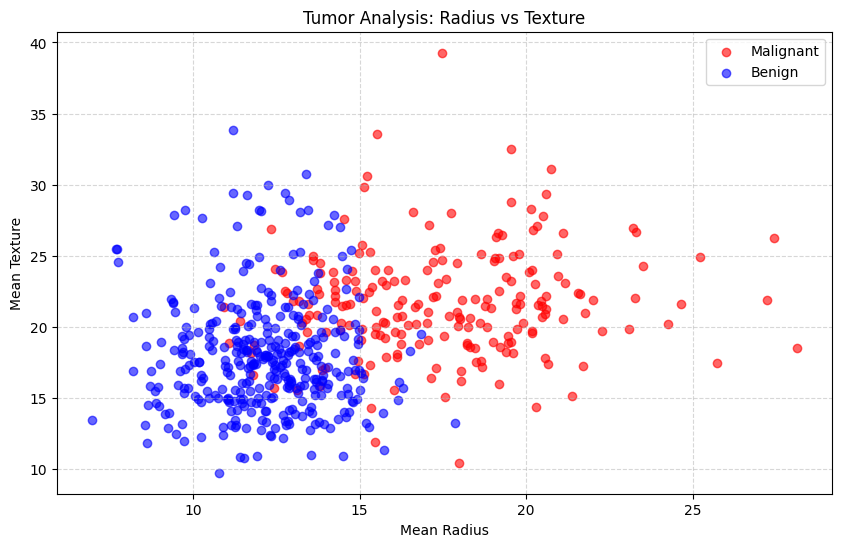

✅ Model Accuracy: 97.37%
--- CLINICAL DIAGNOSIS ---
Result: MALIGNANT
Confidence Level: 100.00%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load the Official Medical Dataset
raw_data = load_breast_cancer()
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
df['target'] = raw_data.target # 0 = Malignant, 1 = Benign

# 2.  Matplotlib Visualization
plt.figure(figsize=(10, 6))
malignant = df[df['target'] == 0]
benign = df[df['target'] == 1]

plt.scatter(malignant['mean radius'], malignant['mean texture'], color='red',
            label='Malignant', alpha=0.6)
plt.scatter(benign['mean radius'], benign['mean texture'], color='blue',
            label='Benign', alpha=0.6)

plt.title("Tumor Analysis: Radius vs Texture")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Data Preparation & Scaling
X = df.drop('target', axis=1)
y = df['target']

# Normalizing data to ensure all medical features have equal weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,
                                                    random_state=42)

# 4. Train the Diagnostic Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. The "Trainer" Prediction Tool 
def get_diagnosis(sample_data):
    # Ensure input is a DataFrame with feature names to avoid warnings
    input_df = pd.DataFrame([sample_data], columns=raw_data.feature_names)
    scaled_input = scaler.transform(input_df)

    prediction = model.predict(scaled_input)
    probability = model.predict_proba(scaled_input)[0]

    result = "BENIGN" if prediction[0] == 1 else "MALIGNANT"
    confidence = np.max(probability) * 100

    print(f"--- CLINICAL DIAGNOSIS ---")
    print(f"Result: {result}")
    print(f"Confidence Level: {confidence:.2f}%")

# Test with the first patient in our test set
print(f"✅ Model Accuracy: {model.score(X_test, y_test)*100:.2f}%")
get_diagnosis(raw_data.data[0])

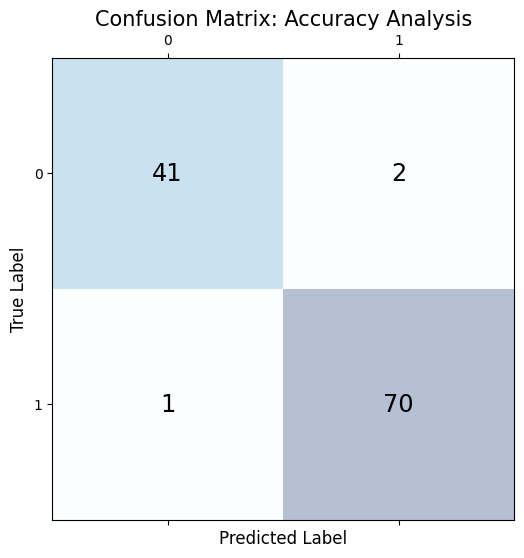


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [9]:
from sklearn.metrics import confusion_matrix, classification_report

# Phase 4 Skill: Detailed Performance Metrics
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualizing the Confusion Matrix using Matplotlib
fig, ax = plt.subplots(figsize=(6, 6))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=cm[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix: Accuracy Analysis', fontsize=15)
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

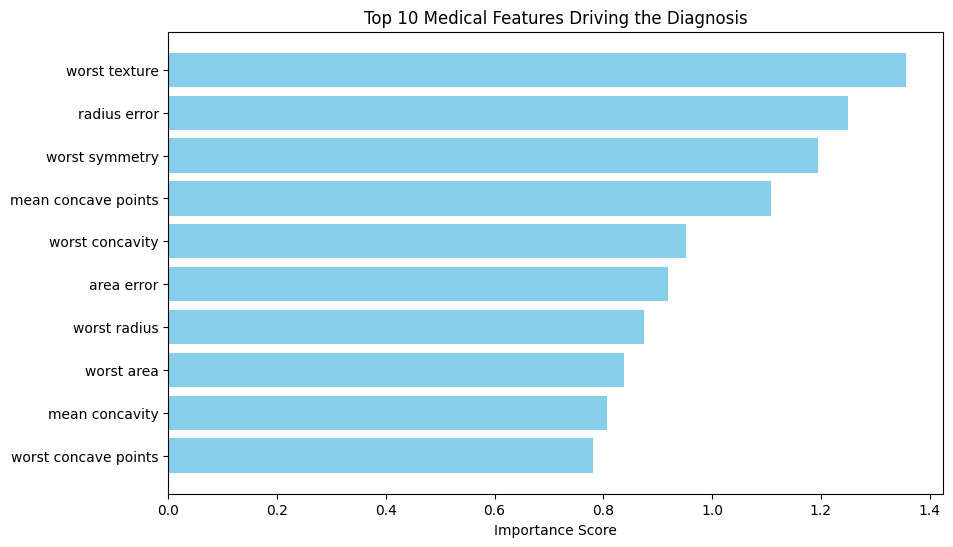

In [10]:
# Phase 2 & 4 Skill: Understanding Feature Impact
importance = np.abs(model.coef_[0])
features = raw_data.feature_names

# Sort and plot top 10 features
indices = np.argsort(importance)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importance[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Top 10 Medical Features Driving the Diagnosis')
plt.xlabel('Importance Score')
plt.show()

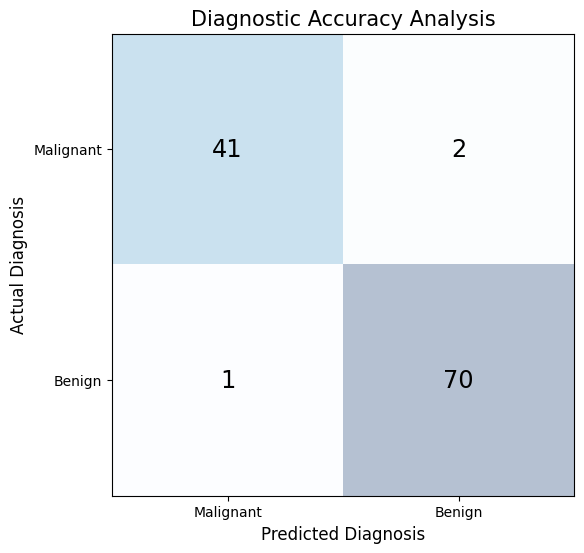

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Generate predictions from the test set
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting the matrix using Matplotlib
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cm, cmap='Blues', alpha=0.3)

# Add the numbers inside the boxes
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', size='xx-large')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Malignant', 'Benign'])
ax.set_yticklabels(['Malignant', 'Benign'])
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.title('Diagnostic Accuracy Analysis', fontsize=15)
plt.show()

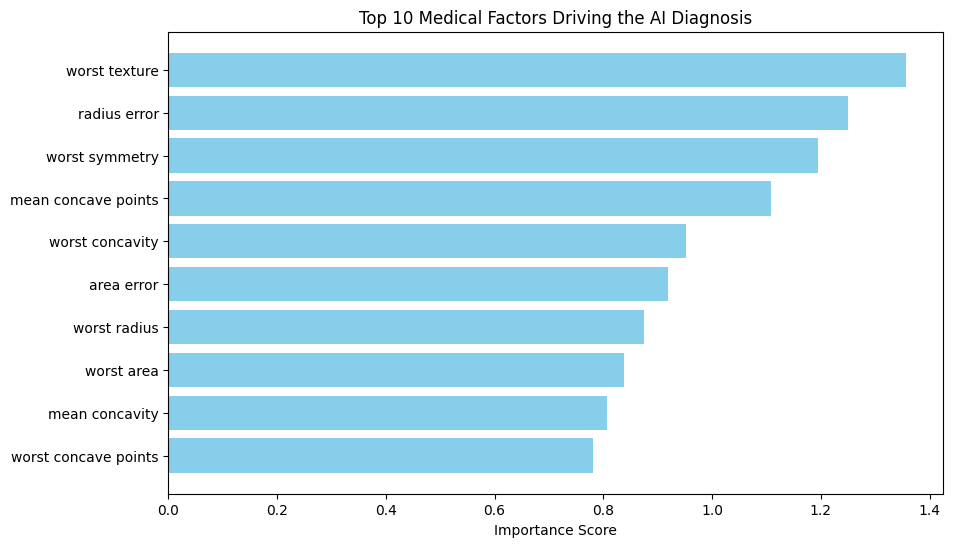

In [12]:
# Extract the importance (weights) from the model
importance = np.abs(model.coef_[0])
feature_names = raw_data.feature_names
sorted_indices = np.argsort(importance)[-10:] # Top 10 features

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(range(10), importance[sorted_indices], color='skyblue')
plt.yticks(range(10), [feature_names[i] for i in sorted_indices])
plt.title('Top 10 Medical Factors Driving the AI Diagnosis')
plt.xlabel('Importance Score')
plt.show()


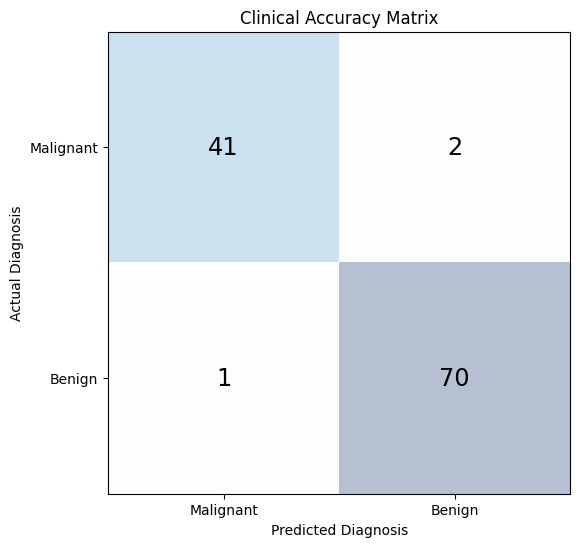

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Generate predictions
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting with Matplotlib
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cm, cmap='Blues', alpha=0.3)

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', size='xx-large')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Malignant', 'Benign'])
ax.set_yticklabels(['Malignant', 'Benign'])
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.title('Clinical Accuracy Matrix')
plt.show()

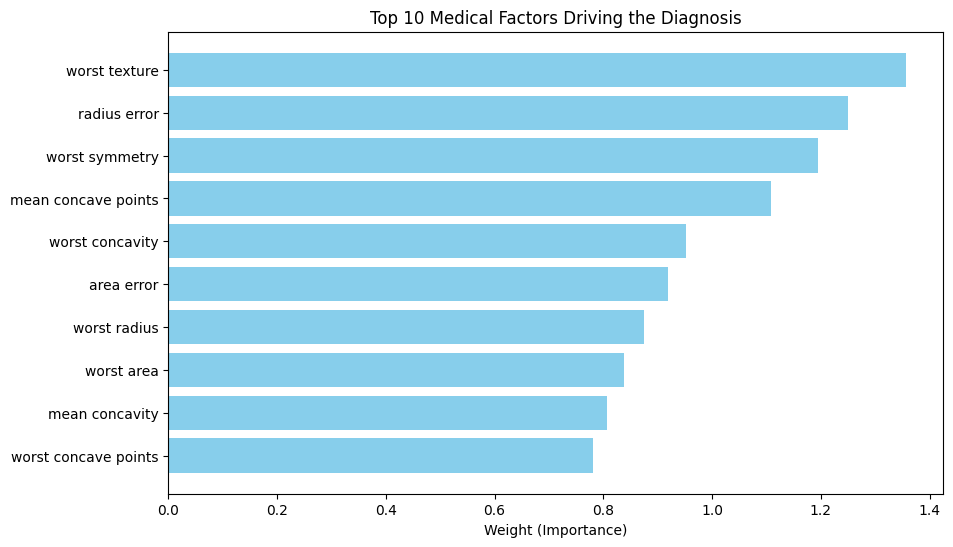

In [16]:
# Calculate feature weights
importance = np.abs(model.coef_[0])
features = raw_data.feature_names
indices = np.argsort(importance)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.barh(range(10), importance[indices], color='skyblue')
plt.yticks(range(10), [features[i] for i in indices])
plt.title('Top 10 Medical Factors Driving the Diagnosis')
plt.xlabel('Weight (Importance)')
plt.show()